# Presentation

For the presentation, pick a few questions from either Part 1 or Part 2 that you found challenging and explain how you answered the question with SQL.  If you did any of the extra credit, present on that.  The presentation should be no longer than 5 minutes and should highlight anything new that you learned.

<h1 align="center">
  <span style="color:#E0A458;">&gt;_</span> SQL Project 3
</h1>
<p align="center" style="color:#2E7D74; font-family:Arial; letter-spacing:3px;">
  CHINOOK &nbsp;&middot;&nbsp; BIGQUERY
</p>

# <font color="purple">Presentation with SQL</font>




1.  <font color="orange"> Chinook (SQL)</font>
2.   <font color="orange">BigQuery (usa_names)</font>
3.   <font color="orange">1910-2021 NM Focus</font>



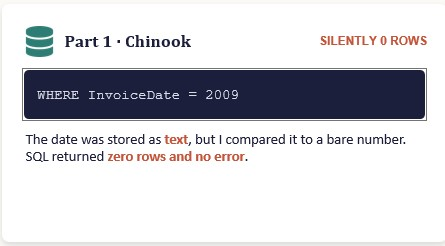

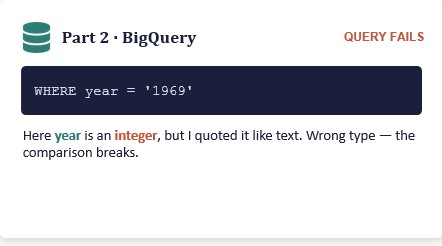

# <font color="orange">SQL Querying Cost Money</font>

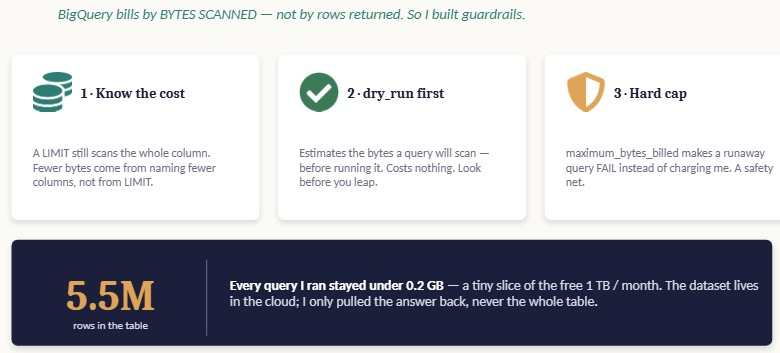

In [ ]:
def dry_run(query):  # My function called dry run with the SQL  string 'query'
    """Estimate bytes scanned WITHOUT running the query. No charge."""
    job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)  # dry= true estimates size of query and use_query_cache = False does not use a cached estimate of the size
    job = client.query(query, job_config=job_config)  # Google BigQuery totals the byte cost but does not charge me
    gb = job.total_bytes_processed / 1e9  # total bytes divided by 1 billion resutl will be in GB
    print(f"[black on bright_white]This query will scan [/] {job.total_bytes_processed:,} bytes ({gb:.4f} GB)" )  # prints and formmats job.total_bytes_processed and gb.4f
    return job.total_bytes_processed

def run_sql(query, max_gb=1.0):
    cfg = bigquery.QueryJobConfig(maximum_bytes_billed=int(max_gb * 1e9))  #Usage from total scan was roughly 4–6 GB
    return client.query(query, job_config=cfg).to_dataframe()

# query runs
print("="*55)

query = """
    SELECT *
    FROM `bigquery-public-data.usa_names.usa_1910_current`

    LIMIT 10
"""

dry_run(query)          # check bytes — should be tiny

print("="*55)
df = run_sql(query)   # then run
df